### Simple Regression

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns

In [2]:
np.random.seed(42)

### Load The Data

In [3]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


### EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  33 non-null     float64
 1   Salary           33 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 660.0 bytes


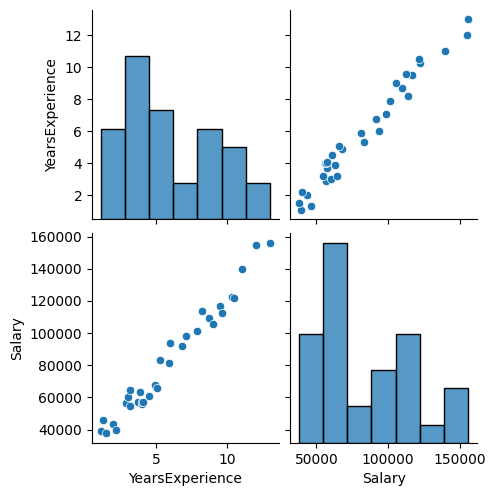

In [19]:
sns.pairplot(df)

In [5]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.983642
Salary,0.983642,1.000000


### Data Prepration

In [6]:
# Split The Data in X and Y
x=df.drop('Salary',axis=1)
y = df['Salary']

In [7]:
x = torch.tensor(x['YearsExperience'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

In [8]:
print(x.shape)
print(y.shape)

torch.Size([33, 1])
torch.Size([33, 1])


### Model Building

In [9]:
# Create a linear Model
model = torch.nn.Linear(in_features=1,out_features=1)

In [10]:
# HYper parameters
epochs = 100
lr = 0.001
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)

### Parameters Before The Training Loop

In [11]:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.7563]], requires_grad=True)
Parameter containing:
tensor([0.6105], requires_grad=True)


### TRaining Loop

In [12]:
errors=[]
for epoch in range(epochs):
    # Forward Propagation
    y_pred = model(x)
    
    #loss Calculations
    loss = loss_function(y_pred,y)

    #zero out the OLD Gradients
    optimizer.zero_grad()

    #Cal The Loss Gradients
    loss.backward()

    #Optimize the model Parameters
    optimizer.step()
    errors.append(loss.item())
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1} Loss = {loss.item():.4f}")

Epoch 10 Loss = 1488874496.0000
Epoch 20 Loss = 335860032.0000
Epoch 30 Loss = 172473616.0000
Epoch 40 Loss = 148577440.0000
Epoch 50 Loss = 144349584.0000
Epoch 60 Loss = 142901856.0000
Epoch 70 Loss = 141853840.0000
Epoch 80 Loss = 140869952.0000
Epoch 90 Loss = 139902816.0000
Epoch 100 Loss = 138945728.0000


In [13]:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[12710.8721]], requires_grad=True)
Parameter containing:
tensor([2655.7825], requires_grad=True)


### Visualization

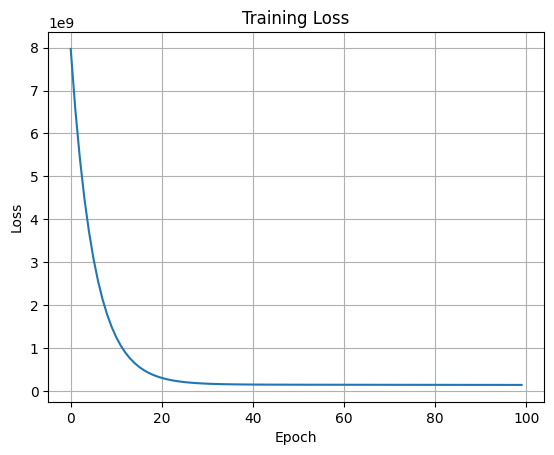

In [14]:
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)


Text(0.5, 1.0, 'Regression Line')

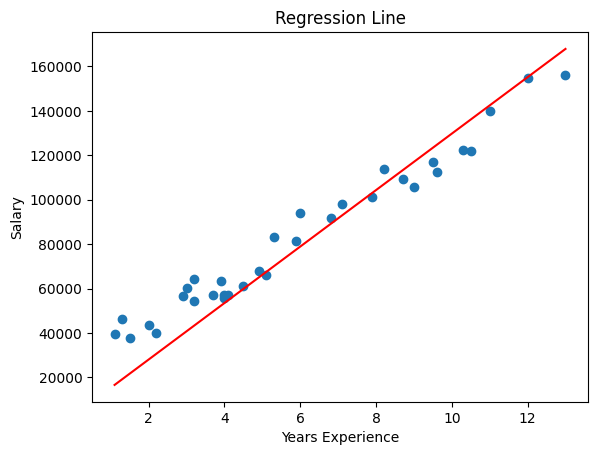

In [15]:
with torch.no_grad():
    pred = model(x)

plt.scatter(x.numpy(), y.numpy())
plt.plot(x.numpy(), pred.numpy(), color="red")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Regression Line")

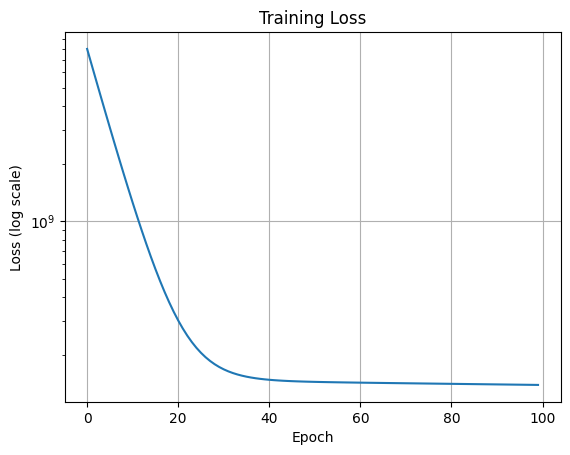

In [16]:
plt.plot(errors)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training Loss")
plt.grid(True)

### Model Inference

In [17]:
with torch.no_grad():
    salary = model(torch.tensor([[15.0]]))
    print(salary)

tensor([[193318.8594]])
